<a href="https://colab.research.google.com/github/vanshkothare/Machine-learning-5th-SEM-project/blob/main/PRACTICAL_NO_05_DL_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest for Fault Detection in Wireless Communication

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/wireless_signal_quality_dataset.csv")

print("First Five Records")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

First Five Records
   Signal_Strength_dBm  SNR_dB  Interference_dB  Distance_m  Frequency_GHz  \
0                  -41       6                0         257            5.0   
1                  -86      25               20         134            2.4   
2                  -73      27                0         385            2.4   
3                  -57       5                0         255            5.0   
4                  -87      15               24          61            5.0   

   Channel_Bandwidth_MHz  Noise_Floor_dBm  Connected_Devices  \
0                    160             -100                 24   
1                    160              -96                 41   
2                     20              -72                 13   
3                    160              -86                  9   
4                     20              -79                 32   

   Estimated_Throughput_Mbps Quality  
0                         18    Poor  
1                         55    Poor  
2         

In [ ]:
X = data.drop("Quality", axis=1)
y = data["Quality"]

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nClasses:")
print(encoder.classes_)


Classes:
['Excellent' 'Fair' 'Good' 'Poor']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy = {:.2f}%".format(accuracy*100))


Accuracy = 88.00%


In [ ]:
print("\nClassification Report")

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))


Classification Report
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        Fair       0.75      1.00      0.86         9
        Good       0.00      0.00      0.00         2
        Poor       1.00      1.00      1.00        13

    accuracy                           0.88        25
   macro avg       0.44      0.50      0.46        25
weighted avg       0.79      0.88      0.83        25



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)



Confusion Matrix
[[ 0  1  0  0]
 [ 0  9  0  0]
 [ 0  2  0  0]
 [ 0  0  0 13]]


In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print("\nFeature Importance")

print(importance)


Feature Importance
Signal_Strength_dBm          0.360444
SNR_dB                       0.207060
Estimated_Throughput_Mbps    0.150236
Interference_dB              0.079427
Distance_m                   0.060098
Noise_Floor_dBm              0.048804
Connected_Devices            0.047951
Channel_Bandwidth_MHz        0.028872
Frequency_GHz                0.017107
dtype: float64


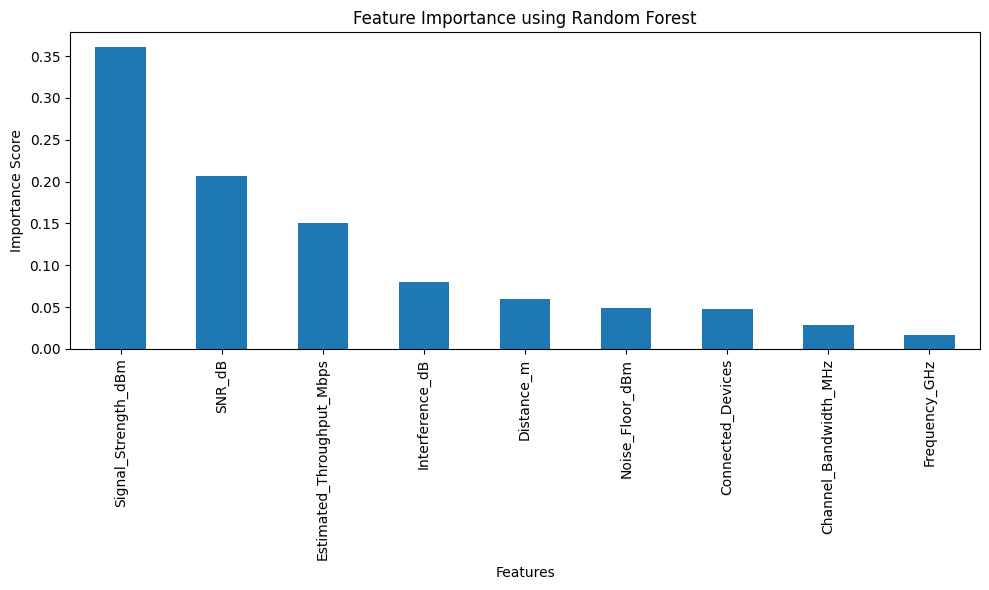

In [ ]:
plt.figure(figsize=(10,6))

importance.plot(kind='bar')

plt.title("Feature Importance using Random Forest")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.show()